In [12]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()

# gpt-4o-mini 는 멀티모달 — 이미지 입력을 그대로 받는다
llm = init_chat_model("openai:gpt-4o-mini")

In [13]:
import base64
import mimetypes


def load_image(path: str) -> str:
    """이미지 파일 → data URL (base64). 비전 모델 입력용."""
    mime = mimetypes.guess_type(path)[0] or "image/jpeg"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    return f"data:{mime};base64,{b64}"

In [14]:
from typing import TypedDict, Annotated, Literal
from langgraph.graph.message import add_messages


class DocentState(TypedDict):
    messages: Annotated[list, add_messages]
    persona: Literal["child", "beginner", "explorer", "healing"]  # 관람객 유형 = 학습 수준
    image: str             # 입력: 이미지 (base64 data URL)
    image_info: str        # router가 채움: 트랙 A일 때 식별된 작가·작품명
    track: Literal["A", "C"]  # router 결과: A=명화 / C=미상
    art_context: str       # analyze 출력: 해설 재료
    docent_script: str     # generate_docent 출력


PERSONA_TONE = {
    "child":    "8살 어린이에게 말하듯. 쉬운 비유와 질문을 섞어 짧고 재미있게. 어려운 용어 금지.",
    "beginner": "미술 입문자에게. 일상적인 비유로 공감대를 만들고 쉬운 단어 중심으로.",
    "explorer": "지식 탐구자에게. 전문 용어와 미술사적 맥락·시대상을 담아 평론 스타일로.",
    "healing":  "위로를 원하는 사람에게. 에세이 톤으로 차분하고 감성적인 묘사 중심으로.",
}

In [15]:
from langchain_core.messages import HumanMessage


def router(state: DocentState) -> dict:
    """이미지를 직접 보고 유명 명화(A)인지 정보 없는 이미지(C)인지 판단 + 작품 식별."""
    resp = llm.invoke([
        HumanMessage(content=[
            {
                "type": "text",
                "text": """이 이미지가 미술사에 기록된 '유명 명화'인지 판단해줘.

                작가·작품이 확실히 특정되는 유명 명화면  ->  A | 작가, 작품명
                그 외 (AI 생성물·일반 이미지·확신 없음)  ->  C

                위 형식으로 한 줄만 답해.""",
            },
            {"type": "image_url", "image_url": {"url": state["image"]}},
        ])
    ])
    text = resp.content.strip()

    if text.upper().startswith("A"):
        identity = text.split("|", 1)[1].strip() if "|" in text else ""
        print(f"[router] track = A  ({identity})")
        return {"track": "A", "image_info": identity}

    print("[router] track = C")
    return {"track": "C"}


def route_by_track(state: DocentState) -> Literal["analyze_masterpiece", "analyze_mood"]:
    return "analyze_masterpiece" if state["track"] == "A" else "analyze_mood"

In [16]:
def analyze_masterpiece(state: DocentState) -> dict:
    """트랙 A: 식별된 명화명 → 작가·시대·화풍 맥락."""
    resp = llm.invoke(
        f"""너는 미술사 전문가야.
        아래 작품 도슨트 해설의 재료가 될 핵심 맥락을 간결히 정리해줘.

        작품: {state['image_info']}

        1. 작가와 시대
        2. 배경/비하인드
        3. 화풍의 특징(색채·구도·기법)"""
    )
    return {"art_context": resp.content, "messages": [resp]}


def analyze_mood(state: DocentState) -> dict:
    """트랙 C: 이미지를 비전으로 분석 → 색감·질감·무드."""
    resp = llm.invoke([
        HumanMessage(content=[
            {
                "type": "text",
                "text": """너는 비주얼 아트 큐레이터야.
                이 이미지의 무드를 분석해줘.

                1. 지배적인 색감·톤
                2. 질감·구도의 분위기
                3. 감정 키워드 3개""",
            },
            {"type": "image_url", "image_url": {"url": state["image"]}},
        ])
    ])
    return {"art_context": resp.content, "messages": [resp]}

In [17]:
def generate_docent(state: DocentState) -> dict:
    """맥락 + 페르소나 → 눈높이 맞춤 도슨트 해설."""
    resp = llm.invoke(
        f"""너는 미술관 도슨트야.
        아래 작품 맥락으로 관람객에게 들려줄 해설을 써줘.

        [작품 맥락]
        {state['art_context']}

        [관람객 눈높이]
        {PERSONA_TONE[state['persona']]}

        위 눈높이에 맞는 톤으로 3~4문단 해설을 작성해줘."""
    )
    return {"docent_script": resp.content, "messages": [resp]}

In [18]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(DocentState)
builder.add_node("router", router)
builder.add_node("analyze_masterpiece", analyze_masterpiece)
builder.add_node("analyze_mood", analyze_mood)
builder.add_node("generate_docent", generate_docent)

builder.add_edge(START, "router")
builder.add_conditional_edges("router", route_by_track)   # 트랙 A/C 분기
builder.add_edge("analyze_masterpiece", "generate_docent")
builder.add_edge("analyze_mood", "generate_docent")
builder.add_edge("generate_docent", END)

graph = builder.compile()

In [19]:
print(graph.get_graph().draw_ascii())

                    +-----------+                  
                    | __start__ |                  
                    +-----------+                  
                          *                        
                          *                        
                          *                        
                     +--------+                    
                     | router |                    
                     +--------+..                  
                  ...            ...               
                ..                  ..             
              ..                      ..           
+---------------------+          +--------------+  
| analyze_masterpiece |          | analyze_mood |  
+---------------------+          +--------------+  
                  ***            ***               
                     **        **                  
                       **    **                    
                 +-----------------+               
            

In [20]:
def run_docent(image_path: str, persona: str):
    result = graph.invoke({
        "image": load_image(image_path),
        "image_info": "",
        "persona": persona,
        "messages": [],
    })
    print(f"===== {image_path} · track {result['track']} · persona {persona} =====")
    if result["track"] == "A":
        print(f"(식별: {result['image_info']})")
    print(result["docent_script"], "\n")
    return result

[router] track = A  (빈센트 반 고흐, 별이 빛나는 밤)
===== The Starry Night.jpg · track A · persona child =====
(식별: 빈센트 반 고흐, 별이 빛나는 밤)
안녕하세요, 여러분! 오늘 우리가 볼 작품은 유명한 화가 빈센트 반 고흐가 그린 "별이 빛나는 밤"이라는 그림이에요. 빈센트는 1800년대에 살았던 화가로, 마음속에 많은 감정을 담아 그림을 그렸어요. "별이 빛나는 밤"은 그가 정신 병원에 있을 때 그린 그림이란다. 그곳에서 그는 세상과 자신을 깊이 있게 바라보았답니다. 여러분도 밤하늘을 바라보며 별을 세어본 적이 있나요?

이 그림에서는 높은 하늘에서 반짝이는 별들이 정말 특별하게 보이죠? 노란색의 별과 차가운 파란색 하늘이 함께 어우러져서 마치 싸움이 일어나는 것 같아요! "별이 빛나는 밤"에서는 별들이 자신의 고통과 외로움을 잊게 해주길 바라며 그려진 것 같아요. 혹시 여러분은 어떤 별을 보고 싶나요?

또한 이 그림의 하늘은 선이 흔들흔들하고, 구름도 소용돌이치는 모습이죠? 마치 하늘이 춤추고 있는 것 같아요! 고흐는 붓으로 두껍게 그리고 휘갈겨서 이렇게 움직임을 만들어냈습니다. 여러분도 이렇게 느껴지는 그림을 그려보고 싶지 않나요?

마지막으로, 이 그림을 보면서 여러분은 어떤 기분이 드나요? 기쁜 기분, 슬픈 기분, 아니면 신비로운 기분? 반 고흐는 이 그림을 통해 그의 마음을 전하려고 했어요. 여러분의 마음속 이야기도 그림으로 표현해보는 건 어떨까요? 함께 해보면 재밌을 거에요! 

[router] track = A  (빈센트 반 고흐, 별이 빛나는 밤)
===== The Starry Night.jpg · track A · persona explorer =====
(식별: 빈센트 반 고흐, 별이 빛나는 밤)
안녕하세요, 여러분. 오늘 우리는 빈센트 반 고흐의 "별이 빛나는 밤"을 살펴보겠습니다. 이 작품은 1889년에 창작되었으며, 고흐가 아르사유 정신병원에서 치료를 받던 시기

{'messages': [AIMessage(content='### 빈센트 반 고흐, 별이 빛나는 밤 도슨트 해설의 핵심 맥락\n\n1. **작가와 시대**: \n   - 빈센트 반 고흐(1853-1890)는 네덜란드 출신의 후기 인상파 화가로, 19세기 후반 프랑스에서 활동. 그의 작품은 예술에 대한 깊은 열정과 감정을 담고 있으며, 현대 미술에 큰 영향을 미쳤다. "별이 빛나는 밤"은 1889년에 그려졌으며, 고흐의 정신적 고뇌와 자연에 대한 경외감을 반영한다.\n\n2. **배경/비하인드**: \n   - 이 작품은 아르사유 정신병원에서의 고흐의 치료를 받던 시기에 창작되었다. 이는 그의 불안정한 정신 상태와 연결되어 있으며, 타락한 세상에서의 고독과 내면의 갈등을 표현한다. 그는 창밖의 풍경을 희망적인 시각으로 재구성하며, 당시의 고통과 혼란을 극복하고자 했다.\n\n3. **화풍의 특징(색채·구도·기법)**: \n   - **색채**: 강렬한 파란색과 황금색의 대비가 특징이며, 꿈꾸는 듯한 분위기를 연출. 색채는 감정의 깊이를 표현하는 중요한 요소로 작용.\n   - **구도**: 역동적인 곡선형의 나무와 불규칙한 형태의 별, 그리고 저녁 하늘의 소용돌이가 조화를 이루면서 자연과 인간의 감정을 시각적으로 연결한다.\n   - **기법**: 일반적으로 두껍고 거친 붓질(임프레션 기법)이 사용되어 생동감을 주며, 텍스처가 뚜렷하게 드러나 감정과 에너지를 전달한다. 고흐의 독특한 스타일은 기계적이지 않고 감각적임을 강조한다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 452, 'prompt_tokens': 99, 'total_tokens': 551, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0,
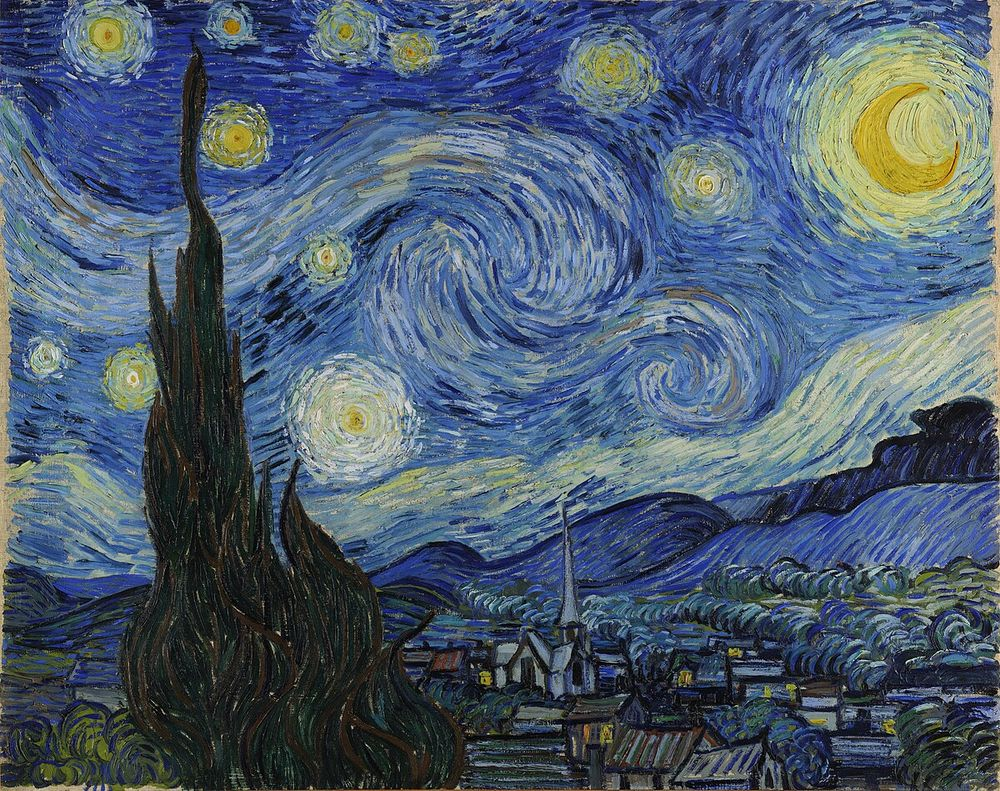

In [21]:
STARRY = "The Starry Night.jpg"   # 실제 명화 이미지 → 트랙 A

run_docent(STARRY, "child")
run_docent(STARRY, "explorer")

[router] track = C
===== anyimage.png · track C · persona healing =====
안녕하세요, 여러분. 오늘 여러분과 함께 감상할 작품은 우리에게 따뜻한 위로와 활기를 전해주는 특별한 이미지입니다. 이 작품은 밝고 화사한 색감으로 우리를 감싸 주며, 놓칠 수 없는 감정의 메시지를 담고 있습니다. 여기에는 오렌지, 갈색, 파란색이 어우러져, 마치 햇살이 가득한 아침의 기분좋은 공기를 떠올리게 합니다. 이런 따뜻한 색조는 일상의 소소한 즐거움을 발견하도록 우리를 초대합니다.

작품의 주인공인 귀여운 캐릭터는 자신이 맡은 업무에 집중하는 모습으로 그려져 있습니다. 그의 부드러운 표정에서는 친근한 느낌이 뚜렷하게 느껴지며, 마치 누군가가 우리의 어깨에 손을 올리며 “괜찮아, 잘 하고 있어”라고 말해주는 듯한 따뜻함이 전해옵니다. 그 주변에는 로켓이 자리 잡고 있어, 일상의 소중한 순간에서 벗어나 새로운 모험을 향해 나아가고자 하는 마음을 상징하는 것 같습니다. 구도의 조화로움은 마음의 부름에 따라 일어서는 그 순간의 아름다움을 포착하고 있습니다.

이 작품은 우리에게 세 가지 감정을 불러일으킵니다. 즐거움, 호기심, 그리고 활기찬 에너지는 모두 우리가 이 세계를 살아가는 데 필요한 요소들입니다. 세상에는 수많은 우여곡절이 있지만, 이 작품을 통해 우리는 다시금 소중한 것들, 즉 작은 즐거움과 새로운 발견의 기회를 느낄 수 있습니다. 우리의 일상 속에서 미소를 짓게 하는 것들이 없던가요? 그 모든 것들이 우리가 삶을 사랑하도록 만드는 원동력이라는 것을 깨닫게 됩니다.

새로운 경험과 긍정적인 감정들은 순간의 작은 보물입니다. 여러분이 이 작품 앞에 서 있을 때, 그런 긍정의 에너지를 온전히 느끼고, 그것을 마음속에 담아내기를 바랍니다. 위로가 필요할 때, 이 작품이 저렴하게 전해주는 따뜻한 메시지와 함께 하루하루의 삶을 더욱 즐겁고 활기차게 살아가시길 소망합니다. 



{'messages': [AIMessage(content='이 이미지의 무드를 분석해보면 다음과 같습니다:\n\n1. **지배적인 색감·톤**: 전체적으로 밝고 화사한 색감이 특징입니다. 주로 오렌지, 갈색, 그리고 파란색 배경의 조화가 따뜻하고 친근한 분위기를 자아냅니다.\n\n2. **질감·구도의 분위기**: 부드러운 질감과 귀여운 캐릭터가 중심에 배치되어 있어 아기자기하고 경쾌한 느낌을 줍니다. 캐릭터는 업무에 집중하는 모습이며, 구도는 강렬한 액션을 암시하는 로켓과 함께 조화롭게 구성되어 있습니다.\n\n3. **감정 키워드 3개**: \n   - 즐거움\n   - 호기심\n   - 활기찬 \n\n이 이미지에서 느껴지는 감정은 긍정적이며, 캐릭터의 표정과 활동적인 요소들이 더해져 유쾌한 분위기를 형성합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 223, 'prompt_tokens': 25567, 'total_tokens': 25790, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_810e56f10f', 'id': 'chatcmpl-DzSCiNME8yXNHKN2qvgzte1vLy2bv', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f
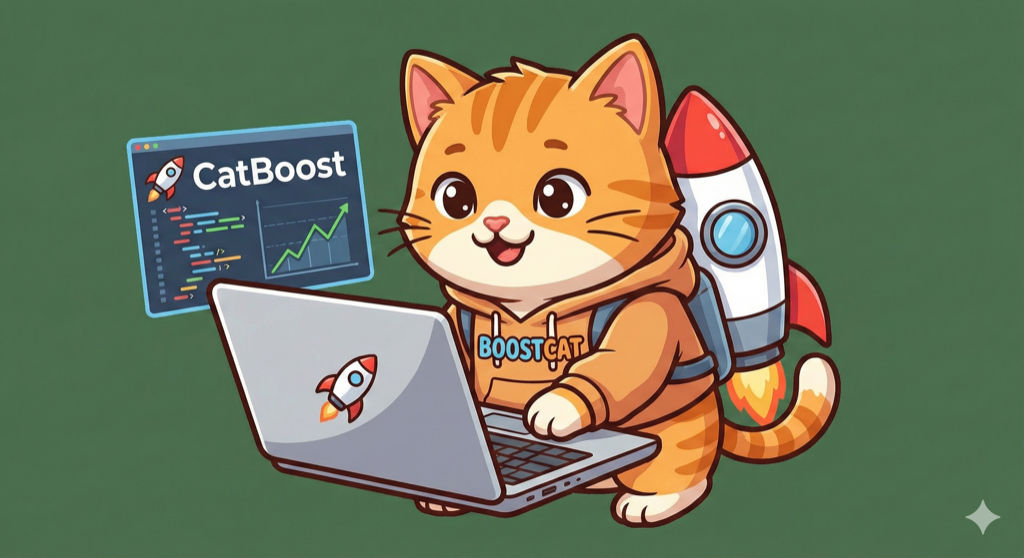

In [22]:
run_docent("anyimage.png", "healing")   # AI 생성 이미지 → 트랙 C